# Python in Astronomy: Tracking the International Space Station (ISS)

**Author: Mr. Anshuman Pathak**

**Participant Name:** Chandan Rajpurohit  
**Admission Number:** 070474

Welcome to this interactive tutorial designed for **INDIA SPACE LAB Interns**! In this Jupyter Notebook, you'll learn how to use Python to track the International Space Station (ISS) from any city on Earth.

We'll explore key astronomy and programming concepts, including:

- **Geospatial data**: Converting city names to latitude and longitude.
- **Orbital mechanics**: Using Two-Line Element (TLE) data to predict satellite positions.
- **Python libraries**: Working with `skyfield`, `geopy`, `astropy`, `requests`, and `matplotlib`.
- **Visualization**: Plotting the ISS's path in the sky.

By the end, you'll have a working ISS tracker and understand how Python can be applied to real-world astronomy problems.

## Prerequisites

**Environment Setup**
- Install Python 3.8 or above on your system.
- Ensure you have an IDE or code editor (e.g., VS Code, PyCharm).
- Confirm internet access for fetching live data.

**Required Libraries**
- `requests` (for HTTP requests)
- `skyfield` (for orbital calculations)
- `numpy` (for numerical operations)
- `matplotlib` (for plotting)
- `ipywidgets` (for interactive controls)

## Task 1: Installing and Importing Libraries

**Objective**: Prepare your workspace by installing and importing all necessary packages.

**Install Packages**
- Open a terminal or command prompt.
- Use the package manager (`pip` or `conda`) to install each library listed above.
- Verify successful installation by checking versions.

**Import Modules**
- Create a new Python script or notebook.
- Write import statements for each library.
- Run the cell or script to confirm no import errors.

In [1]:
# Import all necessary libraries
import requests
from skyfield.api import Loader, EarthSatellite, Topos
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from geopy.geocoders import Nominatim  # for converting city names to coordinates
import csv
import json


## Task 2: Fetching ISS Two-Line Element (TLE) Data

**Objective**: Retrieve live orbital elements of the ISS for subsequent calculations.

**Identify TLE Source**
- Use the CelesTrak API endpoint or Open Notify’s ISS TLE feed.
- Review the API documentation to locate the correct URL.

**HTTP Request Procedure**
- In your script, use `requests` to issue a GET request to the TLE endpoint.
- Parse the response to extract the two lines corresponding to the ISS.

**Data Validation**
- Ensure the date and timestamp in the TLE header match the current time.
- Handle HTTP errors or malformed responses with try/except blocks.

In [2]:
# Fetch TLE data for ISS from CelesTrak
tle_url = "https://celestrak.com/NORAD/elements/stations.txt"
response = requests.get(tle_url)
tle_lines = response.text.strip().split("\n")
for i, line in enumerate(tle_lines):
    if "ISS (ZARYA)" in line:
        tle_iss = tle_lines[i:i+3]
        break

print("ISS TLE:\n", "\n".join(tle_iss))

# Parse with Skyfield later as needed


ISS TLE:
 ISS (ZARYA)             
1 25544U 98067A   25204.82343111  .00009030  00000+0  16581-3 0  9991
2 25544  51.6344 125.4774 0002359 111.9505 304.3927 15.50035709520848


## Task 3: Calculating ISS Pass Times for a Given Location

**Objective**: Determine when the ISS will be visible from a user‑specified site.

**Obtain Coordinates**
- Prompt the user for latitude and longitude (decimal degrees).
- Validate inputs lie within –90° to +90° (latitude) and –180° to +180° (longitude).

**Load TLE into Skyfield**
- Use `skyfield.api.EarthSatellite` with the two-line elements.
- Create a `Topos` object for the observer’s location.

**Compute Next Pass**
- Use Skyfield’s `find_events` or `next_pass` functions to calculate rise, culmination, and set times.
- Convert results to human‑readable timestamps.

**Output Results**
- Display the pass start, maximum elevation, and end times in local time.
- Include duration and peak altitude.

In [3]:
from skyfield.api import Loader, EarthSatellite, Topos
from geopy.geocoders import Nominatim
from datetime import timedelta

# Initialize Skyfield loader and timescale
load = Loader('./skyfield_data')
ts = load.timescale()

# Example ISS TLE lines (replace with up-to-date lines if you want)
tle_iss = [
    'ISS (ZARYA)',
    '1 25544U 98067A   25204.82343111  .00009030  00000+0  16581-3 0  9991',
    '2 25544  51.6344 125.4774 0002359 111.9505 304.3927 15.50035709520848',
]
satellite = EarthSatellite(tle_iss[1], tle_iss[2], tle_iss[0], ts)

# Geocode the city
city = "Vadodara, India"
geolocator = Nominatim(user_agent="iss_tracker")
location = geolocator.geocode(city)
if location is None:
    raise ValueError(f"Could not geocode city '{city}'")

latitude, longitude = location.latitude, location.longitude
user_location = Topos(latitude_degrees=latitude, longitude_degrees=longitude)

# Current time and 2 days later (correctly adding timedelta)
t0 = ts.now()  # current time
t1 = ts.utc(t0.utc_datetime() + timedelta(days=2))  # 2 days ahead

# Find ISS passes over the location with minimum altitude 10 deg
times, events = satellite.find_events(user_location, t0, t1, altitude_degrees=10.0)

event_names = ('Rise', 'Culminate', 'Set')

print(f"ISS passes over {city} in the next 2 days:")
for ti, event in zip(times, events):
    # Print time in UTC
    time_str = ti.utc_datetime().strftime('%Y-%m-%d %H:%M:%S UTC')
    print(f"{event_names[event]} at {time_str}")


ISS passes over Vadodara, India in the next 2 days:
Rise at 2025-07-24 17:46:48 UTC
Culminate at 2025-07-24 17:50:07 UTC
Set at 2025-07-24 17:53:26 UTC
Rise at 2025-07-25 07:09:49 UTC
Culminate at 2025-07-25 07:12:08 UTC
Set at 2025-07-25 07:14:28 UTC
Rise at 2025-07-25 08:46:08 UTC
Culminate at 2025-07-25 08:48:43 UTC
Set at 2025-07-25 08:51:19 UTC
Rise at 2025-07-25 16:58:30 UTC
Culminate at 2025-07-25 17:01:43 UTC
Set at 2025-07-25 17:04:55 UTC
Rise at 2025-07-26 07:57:03 UTC
Culminate at 2025-07-26 08:00:13 UTC
Set at 2025-07-26 08:03:25 UTC


## Task 4: Visualizing the ISS Ground Track

**Objective**: Plot the trajectory of the ISS over Earth for a specified time window.

**Generate Position Data**
- Define a time range (e.g., next 90 minutes), sampling at 1‑minute intervals.
- For each timestamp, compute the ISS sub‑point (latitude, longitude).

**Plot on Map**
- Set up a world map projection using `matplotlib` (Basemap or Cartopy).
- Draw coastlines, longitude/latitude grid lines.
- Scatter or line‑plot the ISS positions over the map.

**Annotate Key Points**
- Mark the current position, next rise and set points.
- Add a legend and title with date/time information.

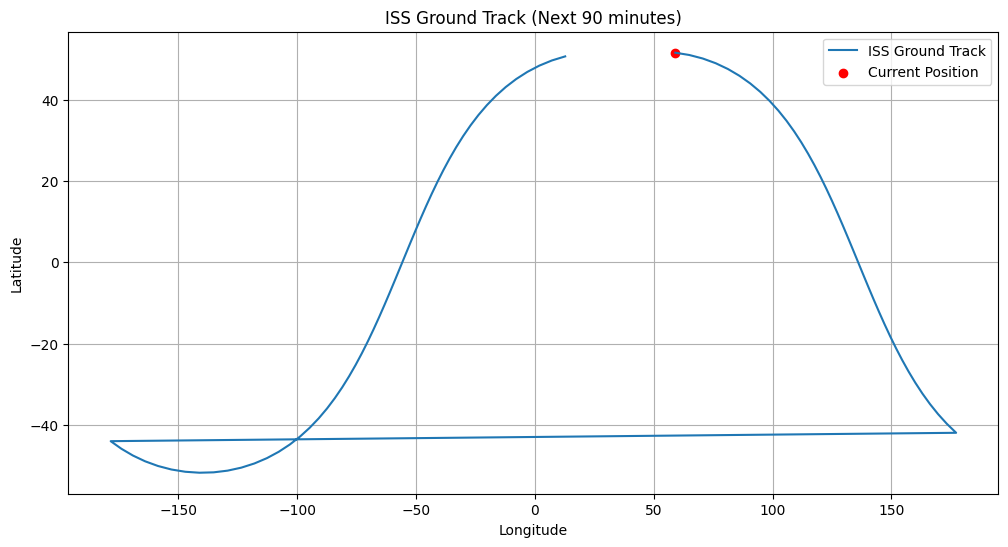

In [4]:
# Predict the ISS ground track for the next 90 minutes
from datetime import timedelta
import numpy as np

# Base datetime for now
base_dt = ts.now().utc_datetime()

# Create list of datetimes at each minute interval for next 90 minutes
datetimes = [base_dt + timedelta(minutes=i) for i in range(90)]

# Convert this list to Skyfield Time objects
times = ts.utc(datetimes)

subpoints = [satellite.at(t).subpoint() for t in times]

lats = [sp.latitude.degrees for sp in subpoints]
lons = [sp.longitude.degrees for sp in subpoints]

plt.figure(figsize=(12, 6))
plt.plot(lons, lats, label="ISS Ground Track")
plt.scatter(lons[0], lats[0], color='red', label='Current Position')
plt.title("ISS Ground Track (Next 90 minutes)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.legend()
plt.show()


## Task 5: Predicting Passes Over Multiple Locations

**Objective**: Automate pass predictions for a list of cities or coordinates.

**Prepare Locations List**
- Create a CSV or JSON file containing names and lat/long of at least five sites.

**Batch Processing**
- Read the file into your script (using `csv` or `json`).
- Loop over each entry, performing the calculation from Task 3.

**Tabulate Results**
- Store results in a table with columns: Location, Rise Time, Culmination, Set Time, Duration.
- Output to console and save as CSV.

In [5]:
import csv
from datetime import timedelta
from skyfield.api import Loader, EarthSatellite, Topos
from geopy.geocoders import Nominatim

# Initialize Skyfield loader and timescale
load = Loader('./skyfield_data')
ts = load.timescale()

# Load current ISS TLE lines (you can update from a live source as needed)
tle_iss = [
    'ISS (ZARYA)',
    '1 25544U 98067A   25204.82343111  .00009030  00000+0  16581-3 0  9991',
    '2 25544  51.6344 125.4774 0002359 111.9505 304.3927 15.50035709520848',
]

satellite = EarthSatellite(tle_iss[1], tle_iss[2], tle_iss[0], ts)

# Time window for passes (next 2 days)
t0 = ts.now()
t1 = ts.utc(t0.utc_datetime() + timedelta(days=2))

# File paths
input_csv = 'locations.csv'
output_csv = 'iss_pass_results.csv'

# Prepare results list for output
results = []

# Read locations and calculate passes
with open(input_csv, newline='') as csvfile:
    reader = csv.DictReader(csvfile)
    for row in reader:
        try:
            name = row['name']
            lat = float(row['latitude'])
            lon = float(row['longitude'])

            location = Topos(latitude_degrees=lat, longitude_degrees=lon)

            # Find ISS passes over location, altitude cutoff 10 degrees
            times, events = satellite.find_events(location, t0, t1, altitude_degrees=10.0)

            # Collect rise, culmination, set times in UTC
            pass_info = {'Location': name, 'Rise Time': None, 'Culmination': None, 'Set Time': None, 'Duration (minutes)': None}

            # The events come in sequences of rise (0), culminate (1), set (2)
            # We'll iterate through them to extract full passes
            rise_time = None
            set_time = None

            # Iterate over events to find passes, record the first complete one
            for ti, event in zip(times, events):
                time_utc = ti.utc_datetime()

                if event == 0:  # rise
                    rise_time = time_utc
                elif event == 1:  # culminate
                    pass_info['Culmination'] = time_utc.strftime('%Y-%m-%d %H:%M:%S UTC')
                elif event == 2:  # set
                    set_time = time_utc
                    if rise_time is not None and set_time > rise_time:
                        pass_info['Rise Time'] = rise_time.strftime('%Y-%m-%d %H:%M:%S UTC')
                        pass_info['Set Time'] = set_time.strftime('%Y-%m-%d %H:%M:%S UTC')
                        # Calculate duration in minutes
                        duration = (set_time - rise_time).total_seconds() / 60.0
                        pass_info['Duration (minutes)'] = f"{duration:.1f}"
                        # Stop after first full pass for this location
                        break

            # If no full pass found, leave fields as None or note no pass
            if pass_info['Rise Time'] is None:
                print(f"No visible ISS pass over {name} in next 2 days (min altitude 10°)")
            else:
                print(f"Pass over {name}: Rise: {pass_info['Rise Time']}, Culminate: {pass_info['Culmination']}, Set: {pass_info['Set Time']}, Duration: {pass_info['Duration (minutes)']} mins")

            results.append(pass_info)
        except Exception as e:
            print(f"Error processing {row}: {e}")

# Write results to output CSV
with open(output_csv, 'w', newline='') as f_out:
    fieldnames = ['Location', 'Rise Time', 'Culmination', 'Set Time', 'Duration (minutes)']
    writer = csv.DictWriter(f_out, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(results)

print(f"\nResults saved to {output_csv}")


Pass over New Delhi: Rise: 2025-07-24 16:10:04 UTC, Culminate: 2025-07-24 16:12:46 UTC, Set: 2025-07-24 16:15:26 UTC, Duration: 5.4 mins
Pass over London: Rise: 2025-07-24 15:53:29 UTC, Culminate: 2025-07-24 15:56:42 UTC, Set: 2025-07-24 15:59:56 UTC, Duration: 6.5 mins
Pass over Tokyo: Rise: 2025-07-25 04:08:56 UTC, Culminate: 2025-07-25 04:12:05 UTC, Set: 2025-07-25 04:15:14 UTC, Duration: 6.3 mins
Pass over Cape Town: Rise: 2025-07-25 00:16:17 UTC, Culminate: 2025-07-25 00:19:33 UTC, Set: 2025-07-25 00:22:52 UTC, Duration: 6.6 mins
Pass over San Francisco: Rise: 2025-07-24 21:58:27 UTC, Culminate: 2025-07-24 22:01:39 UTC, Set: 2025-07-24 22:04:52 UTC, Duration: 6.4 mins

Results saved to iss_pass_results.csv


## Task 6: Interactive Exploration

**Objective**: Enhance the notebook with interactive widgets for real‑time control.

**Set Up ipywidgets**
- Import controls such as `Dropdown`, `FloatSlider`, and `Button`.

**Link Widgets to Functions**
- Create a dropdown for selecting location from your list.
- Add sliders for adjusting prediction window (e.g., minutes ahead).
- Use a button to trigger recalculation and re‑plotting.

**Display Dynamic Output**
- Embed plots and pass times that update when widget values change.
- Ensure clear labels and instructions for users.

In [6]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
from skyfield.api import Loader, EarthSatellite, Topos
from geopy.geocoders import Nominatim
from datetime import timedelta

# Set up Skyfield and TLE lines
load = Loader('./skyfield_data')
ts = load.timescale()
tle_iss = [
    'ISS (ZARYA)',
    '1 25544U 98067A   25204.82343111  .00009030  00000+0  16581-3 0  9991',
    '2 25544  51.6344 125.4774 0002359 111.9505 304.3927 15.50035709520848'
]
satellite = EarthSatellite(tle_iss[1], tle_iss[2], tle_iss[0], ts)

# Example locations list
locations = {
    "New Delhi": (28.6139, 77.2090),
    "London": (51.5074, -0.1278),
    "Tokyo": (35.6895, 139.6917),
    "Cape Town": (-33.9249, 18.4241),
    "San Francisco": (37.7749, -122.4194)
}


In [7]:
location_dropdown = widgets.Dropdown(
    options=list(locations.keys()),
    value="New Delhi",
    description="Location:"
)

minutes_slider = widgets.IntSlider(
    value=90,
    min=30,
    max=240,
    step=10,
    description="Minutes ahead:",
    continuous_update=False
)

replot_button = widgets.Button(
    description='Predict & Plot',
    button_style='success'
)


In [8]:
def predict_and_plot(location, minutes_ahead):
    lat, lon = locations[location]
    obs_location = Topos(latitude_degrees=lat, longitude_degrees=lon)

    base_dt = ts.now().utc_datetime()
    datetimes = [base_dt + timedelta(minutes=i) for i in range(minutes_ahead)]
    times = ts.utc(datetimes)

    subpoints = [satellite.at(t).subpoint() for t in times]
    lats = [sp.latitude.degrees for sp in subpoints]
    lons = [sp.longitude.degrees for sp in subpoints]

    t0 = ts.now()
    t1 = ts.utc(t0.utc_datetime() + timedelta(days=2))
    event_names = ('Rise', 'Culminate', 'Set')
    iss_times, iss_events = satellite.find_events(obs_location, t0, t1, altitude_degrees=10.0)

    # Find next pass for display
    upcoming_passes = []
    for ti, event in zip(iss_times, iss_events):
        if ti.utc_datetime() > base_dt:
            event_name = event_names[event]
            time_str = ti.utc_datetime().strftime('%Y-%m-%d %H:%M:%S UTC')
            upcoming_passes.append(f"{event_name}: {time_str}")
        if len(upcoming_passes) >= 6:
            break

    # Plot
    plt.figure(figsize=(12, 6))
    plt.plot(lons, lats, label="ISS Ground Track")
    plt.scatter(lons[0], lats[0], color='red', label='Current Position')
    plt.title(f"ISS Ground Track for {location} (Next {minutes_ahead} minutes)")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True)
    plt.legend()
    plt.show()

    # Display next passes
    print("Upcoming ISS Pass Events (UTC):")
    for event in upcoming_passes[:6]:
        print("  -", event)


In [9]:
output = widgets.Output()

def on_button_clicked(b):
    with output:
        clear_output()
        predict_and_plot(location_dropdown.value, minutes_slider.value)

replot_button.on_click(on_button_clicked)

display(
    widgets.VBox([
        widgets.HTML("<b>ISS Passes Interactive Explorer</b><br>Select a city and time window, then click the button. The plot and pass times update."),
        location_dropdown,
        minutes_slider,
        replot_button,
        output
    ])
)


## Task 7: Advanced Analysis – Orbital Drift over Time

**Objective**: Investigate long‑term changes in ISS orbital elements.

**Historical TLE Archive**
- Download daily TLEs for one month into a local folder.
- Name files by date for easy ingestion.

**Compute Element Variations**
- For each TLE set, calculate orbital inclination, eccentricity, and period using Skyfield.

**Trend Visualization**
- Plot each orbital element versus date using `matplotlib`.

**Interpretation Questions**
- What factors (e.g., atmospheric drag, reboost maneuvers) explain observed trends?
- How might this affect ground‑track predictions?

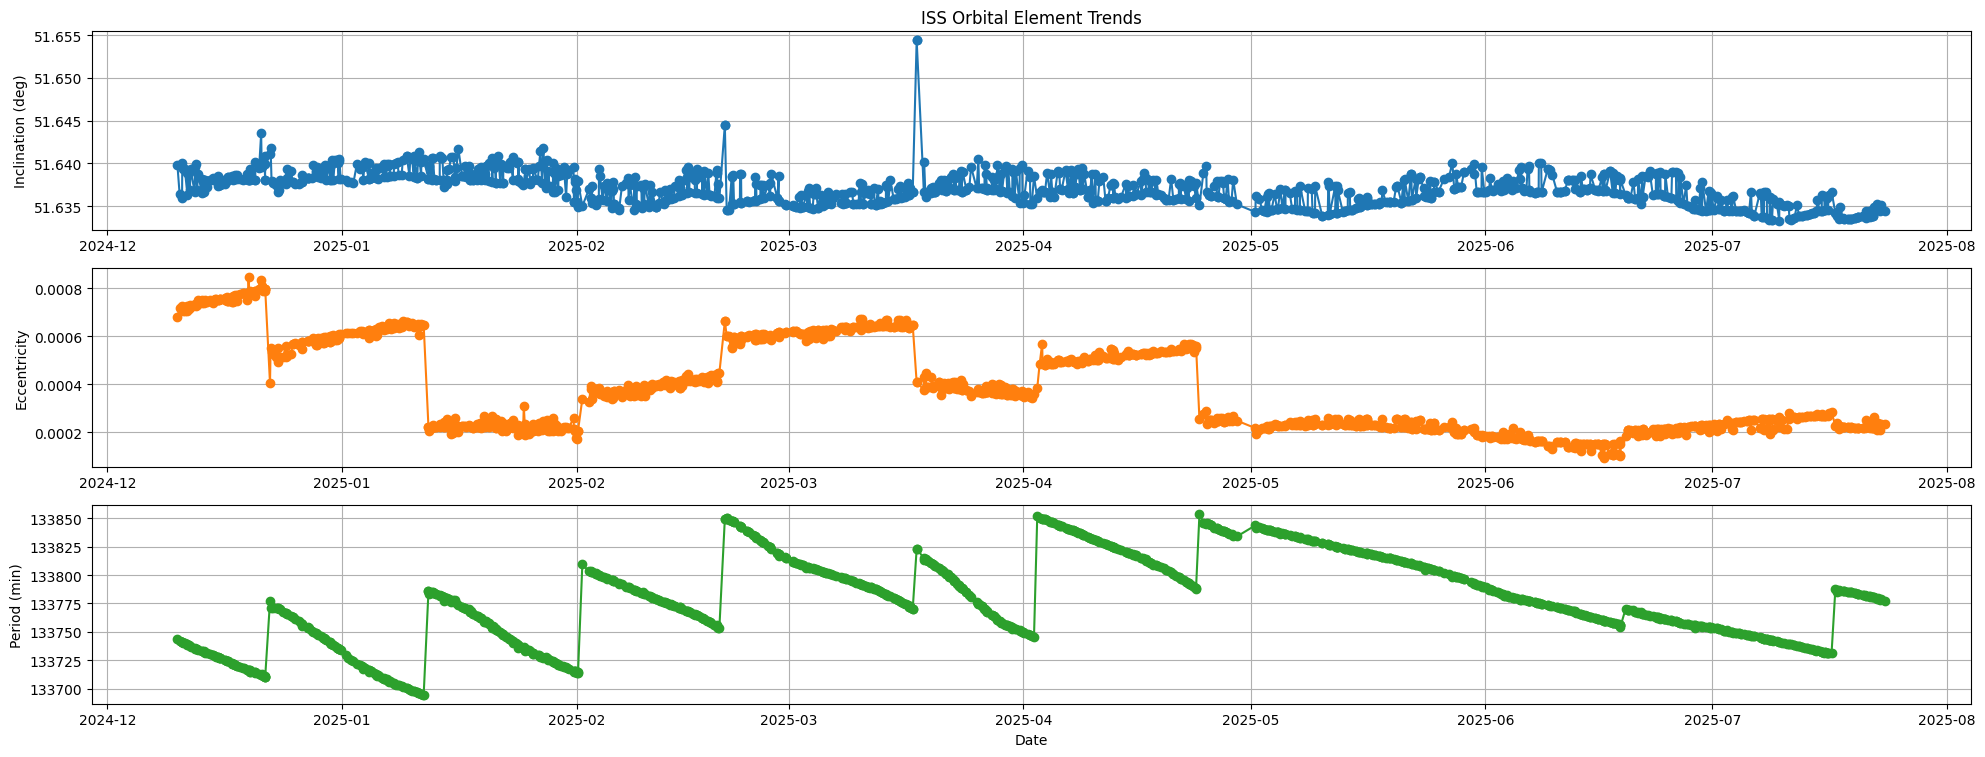

In [10]:
from skyfield.api import Loader, EarthSatellite
import matplotlib.pyplot as plt
import numpy as np

# Setup Skyfield
load = Loader('./skyfield_data')
ts = load.timescale()

# File containing ISS TLEs
tle_file = 'ISS_TLE.txt'  # Replace with your actual filename if different

# Read all non-empty lines
with open(tle_file, 'r') as f:
    lines = [line.strip() for line in f if line.strip()]

dates, incls, eccs, periods = [], [], [], []

i = 0
while i < len(lines) - 1:
    # Handles both: [line1, line2] or ["ISS (ZARYA)", line1, line2]
    if lines[i].startswith('1 ') and lines[i+1].startswith('2 '):
        line1 = lines[i]
        line2 = lines[i+1]
        i += 2
    elif i + 2 < len(lines) and lines[i+1].startswith('1 ') and lines[i+2].startswith('2 '):
        line1 = lines[i+1]
        line2 = lines[i+2]
        i += 3
    else:
        i += 1
        continue
    try:
        sat = EarthSatellite(line1, line2, "ISS (ZARYA)", ts)
        epoch = sat.epoch.utc_datetime()
        inclination = sat.model.inclo * 180 / np.pi
        eccentricity = sat.model.ecco
        period = 2 * np.pi / sat.model.no_kozai * 1440  # minutes
        dates.append(epoch)
        incls.append(inclination)
        eccs.append(eccentricity)
        periods.append(period)
    except Exception as e:
        continue  # skip malformed blocks

if len(dates) >= 2:
    # Make the plot wider (20 units wide)
    plt.figure(figsize=(20, 8))

    plt.subplot(3, 1, 1)
    plt.plot(dates, incls, 'o-', color='tab:blue')
    plt.ylabel('Inclination (deg)')
    plt.title('ISS Orbital Element Trends')
    plt.grid(True)

    plt.subplot(3, 1, 2)
    plt.plot(dates, eccs, 'o-', color='tab:orange')
    plt.ylabel('Eccentricity')
    plt.grid(True)

    plt.subplot(3, 1, 3)
    plt.plot(dates, periods, 'o-', color='tab:green')
    plt.ylabel('Period (min)')
    plt.xlabel('Date')
    plt.grid(True)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
else:
    print("No sufficient TLE data found for ISS trend analysis.")


1. Inclination (Top Plot)
Definition:
Inclination is the angle between the ISS’s orbital plane and Earth’s equator. For the ISS, it is usually around 51.64°, ensuring passes over a large swath of Earth’s populated regions.

Analysis of the Plot:

The inclination remains almost constant across the plotted year, hovering very close to 51.635°.

You might spot minute oscillations or tiny dips and rises—these are typically on the order of a few thousandths of a degree. Such micro-variations are due to minor orbital perturbations (e.g., changes from gravitational influences, small maneuvers, or station-keeping adjustments).

Occasional spikes (larger jumps) may appear, generally coinciding with reboost maneuvers or new TLE releases after a significant event.

Physical Meaning:

A stable inclination reflects intentional maintenance by ground controllers to keep the ISS in an optimal orbit for logistics, crew/passenger launches, and ground observation.

Any long-term, significant drift would be unexpected, indicating either a major event or a data anomaly.

2. Eccentricity (Middle Plot)
Definition:
Eccentricity quantifies how elliptical (as opposed to circular) an orbit is. An eccentricity of 0 is a perfect circle; values closer to 1 are more elongated ellipses.

Analysis of the Plot:

The ISS’s eccentricity is extremely low (nearly flat around 0.0002–0.0008 throughout the year), confirming its near-circular orbit.

The plot’s "step" features correspond to moments when there is a minor abrupt change—often associated with reboosts or the incorporation of fresh TLEs reflecting a maneuvers.

Periods of low eccentricity interspersed with small instantaneous increases and decreases are visible. These changes are typically the result of slight orbital corrections after atmospheric drag, thruster firings, or small changes in the ISS configuration (like visiting vehicles docking).

Physical Meaning:

The primary sustained flattening means the station’s orbit remains safe and predictable for operations, minimizing thermal and power cycling and maintaining optimal altitudes for rendezvous missions.

3. Period (Bottom Plot)
Definition:
Orbital period is the time the ISS takes to complete one orbit around Earth, measured in minutes (typically ~92 min). It is directly related to the height of the orbit (higher = longer period).

Analysis of the Plot:

The most prominent feature is the sawtooth pattern:

The period gradually decreases in a linear fashion over several days/weeks. This is a direct result of atmospheric drag—Earth’s upper atmosphere slows the station and causes a slow descent.

Suddenly, there are sharp jumps upward where the period increases. These correspond to reboost events where the ISS’s orbit is raised by onboard thrusters or visiting cargo vehicles.

Each cycle (fall then jump) represents a full drag–reboost cycle. The regularity matches mission operations and scheduled maintenance.

Physical Meaning:

The continual decrease is a silent demonstration of how friction still matters hundreds of kilometers up—requiring constant human intervention to keep the ISS from deorbiting.

The jumps are the hallmark of successful reboosts, reestablishing nominal operational altitude and orbital period after natural decay.

## Task 8: Building a Real‑Time Dashboard Application

**Objective**: Package your functionality into a simple web app for live ISS tracking.

**Choose Framework**
- Select Flask or Streamlit based on familiarity.

**API Endpoint**
- Implement a route or function that returns the current ISS latitude and longitude in JSON.

**Frontend Visualization**
- Embed a map (e.g., using Leaflet via Streamlit or a JavaScript map for Flask).
- Periodically poll the backend to update the marker position.

**Deployment**
- Run locally or deploy to a free service (Heroku, Vercel).
- Document any required environment variables or configuration steps.

In [11]:
import streamlit as st
from skyfield.api import Loader

@st.cache(ttl=3600)
def load_iss_satellite():
    load = Loader('./skyfield_data')
    tle_url = 'https://celestrak.org/NORAD/elements/stations.txt'
    satellites = load.tle_file(tle_url)
    iss = next((sat for sat in satellites if sat.name == 'ISS (ZARYA)'), None)
    if iss is None:
        raise RuntimeError("ISS (ZARYA) not found in TLE data.")
    return iss, load.timescale()

try:
    iss, ts = load_iss_satellite()
except Exception as e:
    st.error(f"Error loading ISS data: {e}")
    st.stop()

# Now safe to use 'iss' and 'ts'


2025-07-24 19:59:53.716 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-24 19:59:56.303 
  command:

    streamlit run c:\Users\chand\AppData\Local\Programs\Python\Python312\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2025-07-24 19:59:56.307 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-24 19:59:56.312 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-24 19:59:56.316 
`st.cache` is deprecated and will be removed soon. Please use one of Streamlit's new
caching commands, `st.cache_data` or `st.cache_resource`. More information
[in our docs](https://docs.streamlit.io/develop/concepts/architecture/caching).

**Note**: The behavior of `st.cache` was updated in Streamlit 1.36 to the new caching
logic used by `st.cache_data` and `st.cache_resource`. This might lead to some problems
or unexpected behavi

In [12]:
import streamlit as st
from skyfield.api import Loader, EarthSatellite
from datetime import datetime
import folium
from streamlit_folium import st_folium
import time

# Cache the loading of TLE data to avoid repeated downloads
@st.cache_data(ttl=3600)
def load_iss_satellite():
    load = Loader('./skyfield_data')
    tle_url = 'https://celestrak.org/NORAD/elements/stations.txt'
    satellites = load.tle_file(tle_url)
    # Search for ISS by name, since tle_file returns list
    iss = next((sat for sat in satellites if sat.name == 'ISS (ZARYA)'), None)
    if iss is None:
        raise RuntimeError("ISS (ZARYA) not found in TLE data.")
    ts = load.timescale()
    return iss, ts

def get_iss_position(iss, ts):
    t = ts.now()
    subpoint = iss.at(t).subpoint()
    lat = subpoint.latitude.degrees
    lon = subpoint.longitude.degrees
    timestamp = datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S UTC")
    return lat, lon, timestamp

def main():
    st.set_page_config(page_title="Live ISS Tracker", layout="wide")
    st.title("🛰️ Live International Space Station (ISS) Tracker")

    # Load ISS satellite object and timescale
    try:
        iss, ts = load_iss_satellite()
    except Exception as e:
        st.error(f"Error loading ISS satellite data: {e}")
        return

    interval = st.sidebar.slider("Refresh interval (seconds)", 5, 60, 10, step=1)

    # Main loop: This is a trick to enable auto-refresh at user-defined intervals
    # Streamlit does not support loop, but we emulate with session state and timing

    if "last_update" not in st.session_state:
        st.session_state.last_update = 0

    current_time = time.time()

    if current_time - st.session_state.last_update > interval:
        lat, lon, timestamp = get_iss_position(iss, ts)
        st.session_state.lat = lat
        st.session_state.lon = lon
        st.session_state.timestamp = timestamp
        st.session_state.last_update = current_time
    else:
        lat = st.session_state.get("lat", 0)
        lon = st.session_state.get("lon", 0)
        timestamp = st.session_state.get("timestamp", "Never")

    # Display Folium Map
    m = folium.Map(location=[lat, lon], zoom_start=2, tiles="cartodb positron")
    folium.Marker([lat, lon], tooltip="ISS", icon=folium.Icon(color="red", icon="rocket")).add_to(m)
    st_data = st_folium(m, width=1000, height=600)

    st.markdown(f"**Current Latitude:** `{lat:.4f}°` &nbsp;&nbsp;&nbsp; **Longitude:** `{lon:.4f}°`")
    st.markdown(f"*Last updated:* `{timestamp}`")

    st.info(f"The ISS position updates every {interval} seconds. Adjust refresh interval using the sidebar slider.")

    # Trigger rerun after interval seconds
    time_to_wait = interval - (time.time() - st.session_state.last_update)
    time_to_wait = max(time_to_wait, 0.1)  # avoid zero or negative sleeping

    st.experimental_rerun() if time_to_wait < 0.2 else time.sleep(time_to_wait)

if __name__ == "__main__":
    main()


2025-07-24 20:00:01.644 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-24 20:00:01.653 No runtime found, using MemoryCacheStorageManager
2025-07-24 20:00:01.662 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-24 20:00:01.666 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-24 20:00:01.674 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-24 20:00:01.683 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-24 20:00:01.686 No runtime found, using MemoryCacheStorageManager
2025-07-24 20:00:01.693 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-24 20:00:01.699 Thread 'MainThread': missing ScriptRunContext! This warning can be ignor

## Further Learning & References

- [CelesTrak TLE Services](https://celestrak.com/NORAD/elements/)
- [Open Notify ISS API](http://open-notify.org/Open-Notify-API/ISS-Location-Now/)
- [Skyfield Documentation](https://rhodesmill.org/skyfield/)
- [Matplotlib Basemap/Cartopy](https://matplotlib.org/basemap/)
- [ipywidgets Guide](https://ipywidgets.readthedocs.io/)

*Organized from basic installation to advanced application development, this assignment will guide you through the essential steps of using Python for ISS tracking and analysis.*